In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit
import sympy
from processing import filter_region, sort_med_arr, remove_rate
from visualizations import lineplots_4x4, smooth_func
from datetime import datetime
import glasbey

# load prediction arrays, create array objects

In [35]:
folder_path = 'predictions/8-27-2025/'

In [36]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [37]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [38]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [39]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [40]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [41]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [42]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [43]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


### remove anything above 200 spikes/sec

In [11]:
mean_v1_removed = remove_rate(mean_v1, 200)

In [12]:
print('mean shape:', mean_v1_removed.shape)

mean shape: (110, 5312)


In [13]:
np.unique(np.isnan(mean_v1_removed), return_counts = True)

(array([False,  True]), array([582882,   1438]))

In [14]:
var_v1_removed = np.where(np.isnan(mean_v1_removed), mean_v1_removed, var_v1)

In [15]:
print('var shape:', var_v1_removed.shape)

var shape: (110, 5312)


In [16]:
np.unique(np.isnan(var_v1_removed), return_counts = True)

(array([False,  True]), array([582882,   1438]))

In [17]:
test_neuron = 250

In [18]:
mean_v1_removed[..., test_neuron]

array([ 1.2463064 ,  1.24020794,  1.25462661,  1.24655529,  1.2425826 ,
        1.25153601,  1.2398717 ,  1.24163726,  1.2480869 ,  1.24156901,
        6.37779003,  2.54841062,  0.90853661,  4.65332162,  2.21029007,
        1.35951157,  6.54871568,  1.36838745,  0.90229548,  3.83509161,
        3.83487322,  1.35078649,  3.32662263,  8.25588995,  6.0524421 ,
        3.22314709,  1.72692854,  3.21568874, 21.89021402,  1.2630467 ,
        1.63322649,  5.63047903,  5.40039839,  3.32853719, 15.53215022,
        3.39507595,  0.62955402,  6.13283806, 10.41562607,  2.61652664,
        1.27100447,  9.6138177 ,  4.62776532, 13.49668428,  2.41314971,
        3.00902056,  5.39590202,  3.55865272,  6.25919223,  1.06665893,
        0.72649008,  3.1069436 ,  6.3636409 ,  2.24445013,  4.06503166,
        3.88841465,  3.19797114,  9.17677807, 17.50732809,  1.05598657,
        1.20878679,  1.27737361,  2.52204806,  1.12632903,  1.30531135,
        1.08834569, 18.82170198,  1.74326626,  4.27722898,  2.21

In [19]:
var_v1_removed[..., test_neuron]

array([5.89519778e-03, 6.25225449e-03, 5.64696894e-03, 7.58986399e-03,
       8.44021462e-03, 8.26533545e-03, 6.82200535e-03, 6.09422311e-03,
       5.67081193e-03, 1.00324913e-02, 2.23116135e-01, 4.72871449e-02,
       1.70939150e-03, 1.10786283e-01, 3.36602995e-02, 8.61004195e-03,
       2.18050575e-01, 1.12997696e-02, 4.55823124e-03, 5.70135352e-02,
       7.09870565e-02, 5.83171457e-03, 9.25808855e-02, 7.42191340e-01,
       2.33131671e-01, 5.28287135e-02, 9.60795727e-03, 9.09330979e-02,
       4.70275761e+00, 8.48655071e-03, 1.77596737e-02, 2.08138842e-01,
       1.34898624e-01, 4.03271419e-02, 2.13739022e+00, 8.47248433e-02,
       1.00310265e-03, 3.02719337e-01, 7.41405904e-01, 4.72942837e-02,
       5.21759589e-03, 5.27805192e-01, 1.62557925e-01, 1.02839045e+00,
       2.79139484e-02, 7.82202498e-02, 1.49322907e-01, 1.14970853e-01,
       3.52514036e-01, 5.78027666e-03, 6.37661664e-04, 5.82232829e-02,
       2.63737339e-01, 1.67510495e-02, 1.01280631e-01, 1.08535081e-01,
      

### get indices to sort

In [20]:
print(f'unique counts for mean_arr:', np.unique(np.isnan(mean_v1_removed), return_counts = True))
print(f'unique counts for var_arr:', np.unique(np.isnan(var_v1_removed), return_counts = True))
print('ensure that we have the same counts for both arrays')

unique counts for mean_arr: (array([False,  True]), array([582882,   1438]))
unique counts for var_arr: (array([False,  True]), array([582882,   1438]))
ensure that we have the same counts for both arrays


In [ ]:
# run this when wanting to use array with removed values
med_arr = np.nanmedian(mean_v1_removed, axis = 0)
med_arr.shape

(5312,)

In [46]:
# run this when wanting to use array WITHOUT removed values
med_arr = np.nanmedian(mean_v1, axis = 0)
med_arr.shape

(5312,)

In [47]:
for med_num in med_arr: print(med_num)

3.974802479445934
2.3593027226626875
2.7362008299678564
4.895194533690811
4.159150126725436
4.622548931688071
3.8818444656580686
15.556875945329667
9.279563005566597
3.154792268797755
11.045706401318311
11.950191638693212
16.900227708444
7.661633794233203
3.033049823902547
9.30696840506047
6.4384572376310825
6.047185640856624
11.741959682404996
2.748698159493506
5.376979952007532
32.34041048392653
9.889155838564038
4.96723891787231
4.9444513311982154
8.144839701205491
4.180796727389097
5.93926571033895
4.030008012950421
1.8058063982985915
7.819662510082125
2.6598577235639094
7.505931153818965
11.608138296306134
7.710553907603026
6.866133442521095
3.936572218760848
6.677319190055131
11.478807716667653
2.959846276640892
10.883172839507461
2.4146774923428893
8.800222636014222
8.321388820223511
6.008964550942183
3.6290272524207827
9.978706243857742
2.130712605416775
5.477237200438976
5.65389513477683
28.369277135431766
16.382591464966538
8.144303661733865
4.694839561488479
12.6184185665845

In [48]:
sort_indices = np.argsort(med_arr)[::-1]

In [49]:
len(sort_indices)

5312

In [50]:
# use this for when we remove above x rate
mean_v1_sorted = mean_v1_removed[..., sort_indices]
var_v1_sorted = var_v1_removed[..., sort_indices]

In [51]:
# use this OTHERWISE
mean_v1_sorted = mean_v1[..., sort_indices]
var_v1_sorted = var_v1[..., sort_indices]

In [53]:
for neuron in range(mean_v1_sorted.shape[1]):
    print(np.nanmedian(mean_v1_sorted[..., neuron]))

171.38495882749558
101.54519626885653
94.49687044247985
89.33933751612902
88.69355226486921
73.27105030372739
71.10828003756703
67.6045885861665
61.959355877041816
61.37937041044235
59.469200870543716
58.768830648139115
56.09253716938198
55.89795800149441
55.2687453892082
54.079851799756284
52.80393466621638
50.72823161497712
49.91323401540518
48.73878699541092
48.383089814931154
48.26628786623478
47.50984756365418
46.57595436573028
46.5336930051446
46.17690957084298
46.159384136572484
44.89896320953965
44.79695196434855
44.009024114906794
43.796159941852096
43.42643831774592
42.952280337810514
41.65624650403858
41.60993857957423
40.832148746848105
40.389421806037426
40.24494306921959
39.53064896084368
38.40419747754932
38.23513535104692
37.70035556644201
37.64037614643574
37.212576777637004
36.91366429895163
36.657881516516206
36.222396193034946
36.202972593382
36.09766781143844
35.76148193225265
35.42248351439834
35.40452730089426
35.363621720522644
35.22180962406099
34.7926047116518

#### *note that this code works and has been checked properly up to here*

In [55]:
mean_v1_sorted[...,110]

array([ 27.58621029,  27.49326203,  27.74186317,  27.8641814 ,
        27.75378117,  27.9842042 ,  27.48730532,  27.62590874,
        27.81069463,  27.19156086,   9.36700011,  78.67660087,
        15.17724494,  52.48247386,  26.84862817,  25.67521892,
        58.68084727,  27.49477887,  41.13894647,  23.20403724,
        36.13735426,  22.96544245,  37.03151693,  32.60613441,
        42.47705709,  29.00288458,  18.06784184,  23.15266554,
        92.36054953,  27.41652076,  16.09080308,  18.9906505 ,
        45.57561194,   8.99358998,  54.71812402,  32.98455828,
        11.59250499,  32.04121749,  41.98076186,  49.52427398,
        21.5492736 ,  88.13281468,  40.99231965,  16.83124314,
        23.51044848,  17.48271762,  27.93270405,  16.77871171,
        49.30606682,  22.55847315,  13.12748372,  15.91697825,
        33.30800488,  37.6241968 ,  19.91928893,  35.34224598,
        18.17380183,   6.07395201,  35.54455002,  11.860762  ,
        16.23889357,  25.26638534,  43.34310227,  20.91

In [56]:
var_v1_sorted[..., 110]

array([3.41088055e+00, 4.35853471e+00, 3.39939292e+00, 3.66867931e+00,
       4.18822061e+00, 4.52946571e+00, 4.35891428e+00, 3.64760233e+00,
       3.34336074e+00, 3.93591698e+00, 3.96504457e-01, 2.86459856e+01,
       1.12212405e+00, 1.58748844e+01, 3.31402942e+00, 4.31909573e+00,
       1.91889126e+01, 3.97706124e+00, 8.09664938e+00, 2.40573788e+00,
       8.96827926e+00, 2.25046461e+00, 6.85997662e+00, 7.84671649e+00,
       9.33114738e+00, 5.43733843e+00, 1.39057365e+00, 3.36705637e+00,
       3.69315043e+01, 3.61583875e+00, 1.88323540e+00, 1.99683332e+00,
       9.13427869e+00, 3.68229747e-01, 1.90276352e+01, 7.41227548e+00,
       4.57989937e-01, 7.35798128e+00, 8.99443745e+00, 1.20352131e+01,
       2.25827388e+00, 3.58406730e+01, 7.26080902e+00, 1.35324082e+00,
       2.72135301e+00, 1.81437786e+00, 2.46159567e+00, 1.36242684e+00,
       1.36116725e+01, 3.60028045e+00, 5.39507719e-01, 1.38641955e+00,
       4.83608352e+00, 8.20012809e+00, 2.25376387e+00, 8.51888972e+00,
      

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\visualizations.py:816: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


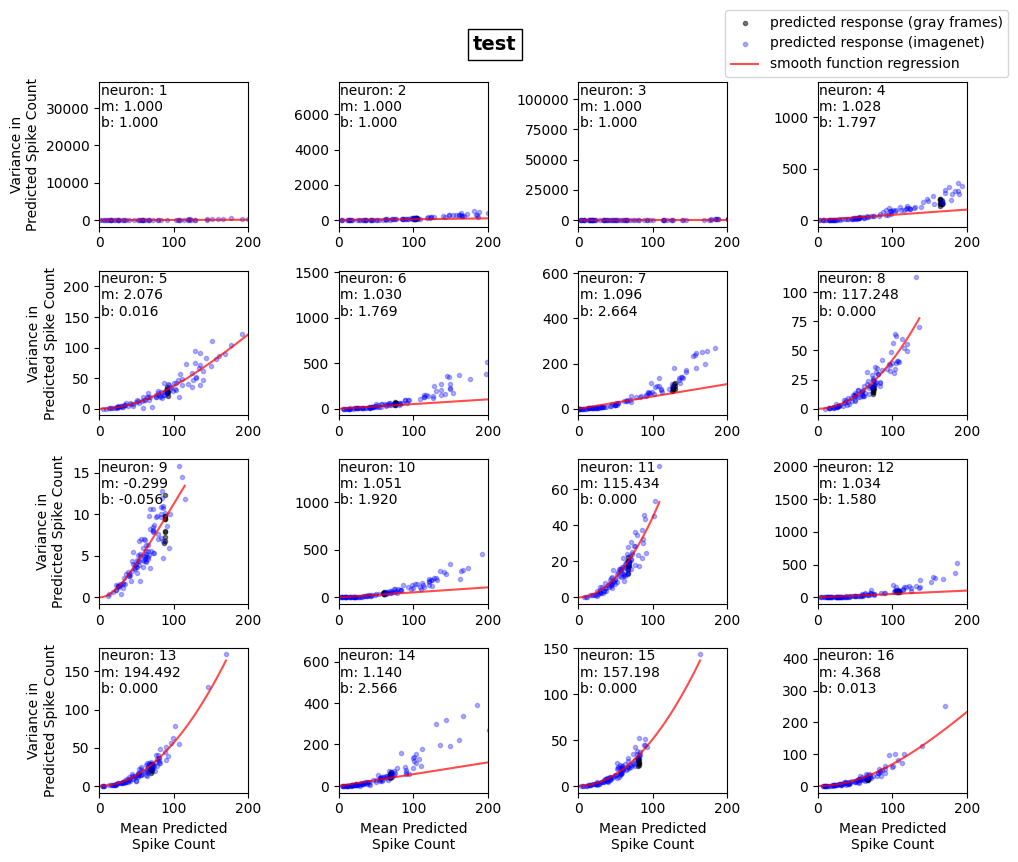

In [58]:
lineplots_4x4('test', mean_v1_sorted, var_v1_sorted)

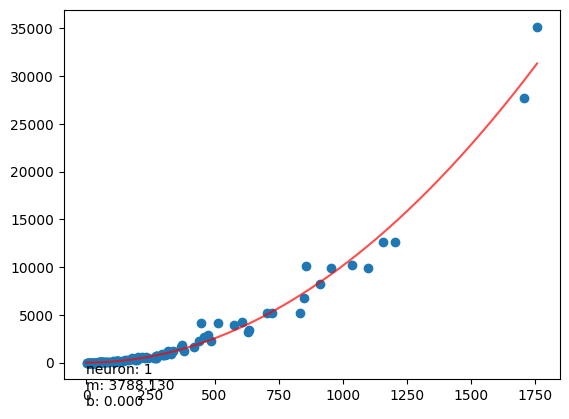

In [95]:
neuron = 0
mean_masked = mean_v1_sorted
var_masked = var_v1_sorted

mask = ~np.isnan(mean_masked[..., neuron]) & ~np.isnan(var_masked[..., neuron])

x_nonan = mean_masked[..., neuron][mask]
y_nonan = var_masked[..., neuron][mask]

params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1,0.001])
x_max = np.max(x_nonan)

y_pred = smooth_func(np.linspace(0, x_max, 1000), params[0], params[1])
plt.plot(np.linspace(0, x_max, 1000), y_pred, color='r', label='smooth function regression', alpha=0.7)
plt.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left')

plt.scatter(x_nonan, y_nonan)
plt.show()

# adjusting scatter plot

In [101]:
# per ralf's comments, play around with scaling

def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron]) & ~np.isnan(var_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, 0.001])
        x_min, x_max = ax.get_xlim()
        y_pred = smooth_func(np.linspace(0, x_max, 1000), params[0], params[1])
        ax.plot(np.linspace(0, x_max, 1000), y_pred, color='r', label='smooth function regression', alpha=0.7)
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers
        
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

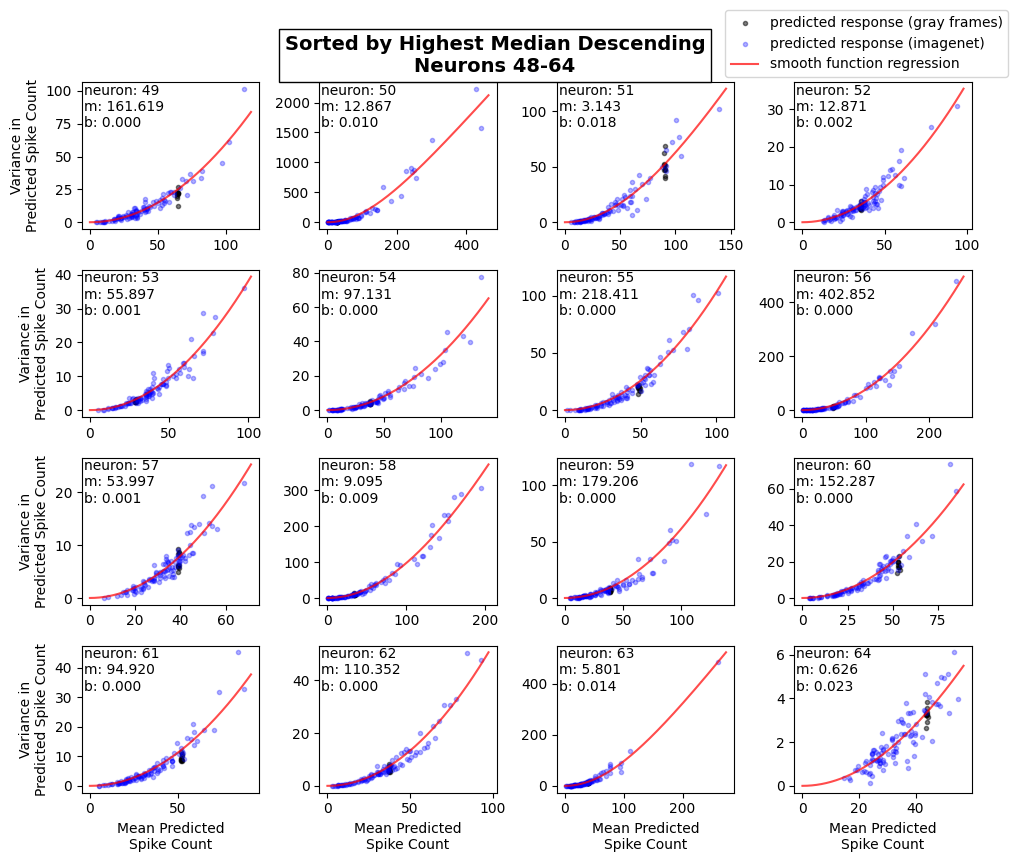

In [107]:
lineplots_4x4('Sorted by Highest Median Descending\nNeurons 48-64', mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(48, 64)])

# plot in log space

In [108]:
def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan), 100), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers

        ax.set_xscale('log')
        ax.set_yscale('log')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

# final function (september 29th)

In [113]:
def lineplots_4x4(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], savefig = False, logspace = False):
    """
    Parameters
    ----------
    main_title: str
        title for plot
    mean_masked: np.array
        mean array of data
    var_masked: np.array
        array of variance data
    neurons: list (ints)
        list of neurons to plot, defualts to first 16
    savefig: bool 
        whether or not to save figure to computer
    Returns
    -------
    plt.show()
        scatter plots with regression shown
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 1_000_000, p0 = [1, .001])
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan), 100), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        #ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers

        if logspace: 
            ax.set_xscale('log')
            ax.set_yscale('log')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

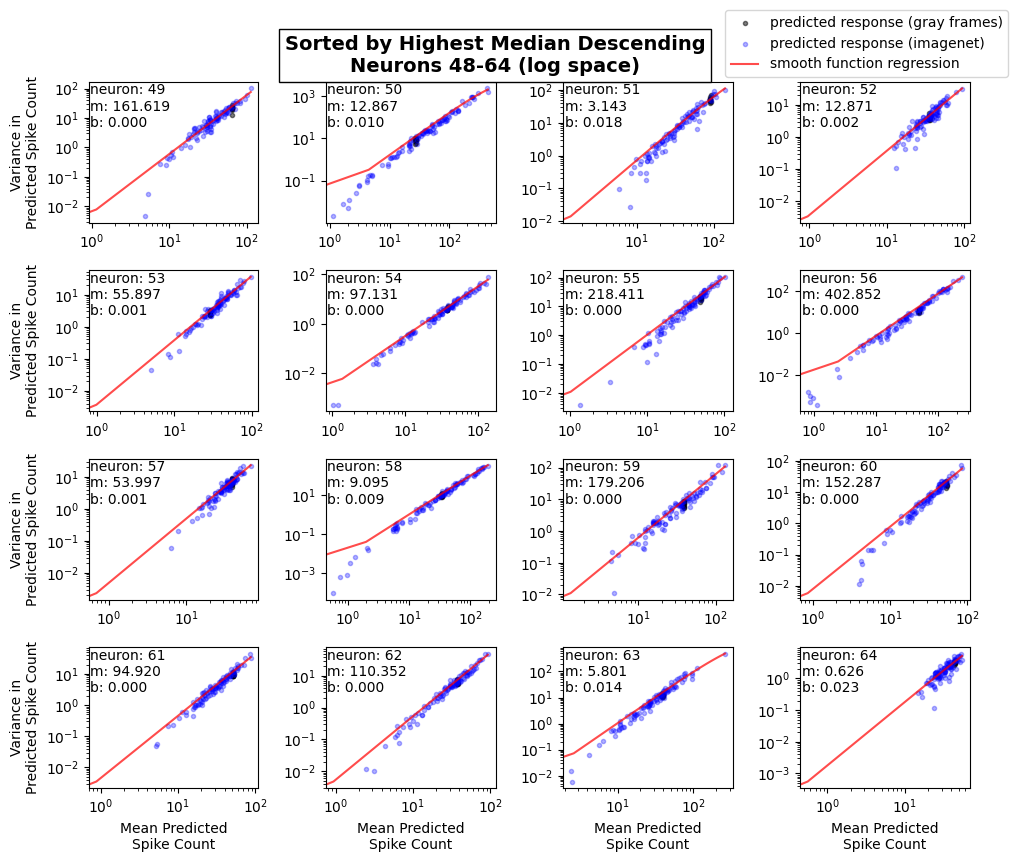

In [115]:
lineplots_4x4('Sorted by Highest Median Descending\nNeurons 48-64 (log space)', mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(48, 64)], logspace = True )